Packages loaded successfully.
Sites directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/sites

Finals directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/finals

USGS Helene landslide file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/usgs_landslides/virginia/helene_landslides_virginia.geojson

DEM file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/processed/southwest_virginia_dem_utm17n.tif

Slope file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/processed/southwest_virginia_slope_degrees.tif

Land-cover file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/landcover/processed/southwest_virginia_nlcd_2021_utm17n.tif

Southwest Virginia study boundary:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/dem/southwest_virginia_boundary.geojson

Matching paramet

Matching 10 controls per treatment:   0%|          | 0/27 [00:00<?, ?it/s]


treatment_0026 obtained only 4 of 10 required controls.

Counterfactual sites selected: 260
Treatments without 10 controls: 1

Final complete treatment sites: 26
Final counterfactual sites: 260
Controls per treatment: 10

Treatment centers saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/sites/treatment_centers.geojson

Counterfactual centers saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/sites/counterfactual_centers.geojson

Treatment image windows saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/sites/treatment_sites.geojson

Counterfactual image windows saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/sites/counterfactual_sites.geojson

Combined site file saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/sites/all_sites.geojson

Final site counts by group:
group
counterfactual    260
treatment          26
Name: count, dtype: int64

M

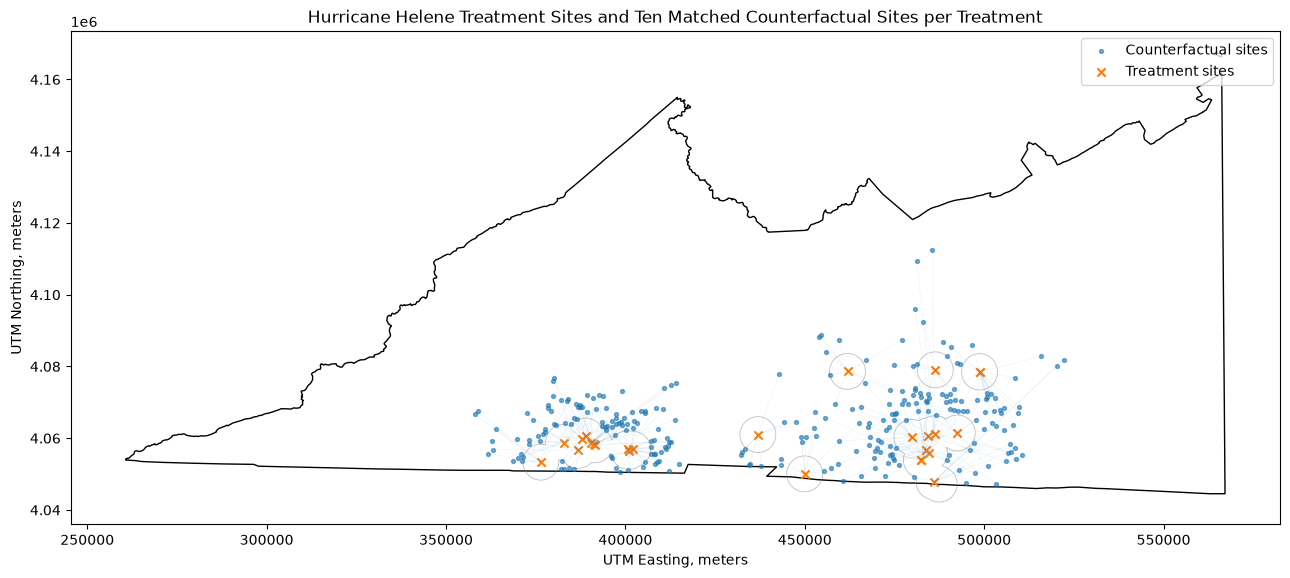


Site map saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/sites/treatment_counterfactual_sites_map.png

MATCHING QUALITY CHECK

Match-quality counts:
match_quality
strict    260
Name: count, dtype: int64

Elevation-difference summary:
count    260.000000
mean      15.526028
std       17.022070
min        0.015686
25%        4.834534
50%       10.362259
75%       19.349014
max      129.149841
Name: elevation_difference_m, dtype: float64

Slope-difference summary:
count    260.000000
mean       0.827952
std        1.002635
min        0.003546
25%        0.211490
50%        0.504810
75%        1.096044
max        6.003355
Name: slope_difference_deg, dtype: float64

Treatment-control distance summary, kilometers:
count    260.000000
mean      13.403323
std        7.280729
min        5.037900
25%        8.377098
50%       11.776986
75%       16.189900
max       51.145041
Name: distance_km, dtype: float64

NLCD class matching:
nlcd_class
41    170
81     20
43 

In [1]:
# =============================================================================
# 06_create_sites.ipynb
#
# Purpose:
# Create treatment and counterfactual satellite-image sites for the
# Hurricane Helene study in southwest Virginia.
#
# Design:
#   - One treatment site per USGS-mapped Helene landslide location
#   - Ten matched counterfactual sites per treatment site
#   - Counterfactuals must be at least 5 km from every treatment location
#   - Matching variables:
#       * NLCD land-cover class
#       * Elevation
#       * Terrain slope
#       * Geographic distance
#
# Expected output with 26 treatment sites:
#   - 26 treatment sites
#   - 260 counterfactual sites
#   - 286 total sites
#
# Main outputs:
#
# datasets/sites/
#   treatment_centers.geojson
#   counterfactual_centers.geojson
#   treatment_sites.geojson
#   counterfactual_sites.geojson
#   all_sites.geojson
#   counterfactual_candidates.geojson
#   landslide_exclusion_zone.geojson
#   treatment_counterfactual_sites_map.png
#
# datasets/metadata/
#   site_matching_table.csv
#   site_matching_summary.csv
#
# datasets/finals/
#   treatment_sites.geojson
#   counterfactual_sites.geojson
#   all_sites.geojson
#   site_matching_table.csv
# =============================================================================


# =============================================================================
# 1. Load packages
# =============================================================================

from pathlib import Path
import shutil

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from shapely.geometry import Point, LineString
from tqdm.auto import tqdm

print("Packages loaded successfully.")


# =============================================================================
# 2. Define project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

BOUNDARIES_DIR = BASE_DIR / "boundaries"
SITES_DIR = BASE_DIR / "sites"
FINALS_DIR = BASE_DIR / "finals"
METADATA_DIR = BASE_DIR / "metadata"

USGS_DIR = BOUNDARIES_DIR / "usgs_landslides"
DEM_DIR = BOUNDARIES_DIR / "dem"
LANDCOVER_DIR = BOUNDARIES_DIR / "landcover"

for folder in [
    SITES_DIR,
    FINALS_DIR,
    METADATA_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Sites directory:")
print(SITES_DIR)

print("\nFinals directory:")
print(FINALS_DIR)


# =============================================================================
# 3. Locate required input files
# =============================================================================

LANDSLIDE_FILE_CANDIDATES = [
    (
        USGS_DIR
        / "virginia"
        / "helene_landslides_virginia.geojson"
    ),
    (
        USGS_DIR
        / "helene_landslides_virginia.geojson"
    ),
]

DEM_FILE_CANDIDATES = [
    (
        DEM_DIR
        / "processed"
        / "southwest_virginia_dem_utm17n.tif"
    ),
    (
        DEM_DIR
        / "southwest_virginia_dem_utm17n.tif"
    ),
]

SLOPE_FILE_CANDIDATES = [
    (
        DEM_DIR
        / "processed"
        / "southwest_virginia_slope_degrees.tif"
    ),
    (
        DEM_DIR
        / "southwest_virginia_slope_degrees.tif"
    ),
]

LANDCOVER_FILE_CANDIDATES = [
    (
        LANDCOVER_DIR
        / "processed"
        / "southwest_virginia_nlcd_2021_utm17n.tif"
    ),
    (
        LANDCOVER_DIR
        / "southwest_virginia_nlcd_2021_utm17n.tif"
    ),
]

STUDY_BOUNDARY_CANDIDATES = [
    (
        DEM_DIR
        / "southwest_virginia_boundary.geojson"
    ),
    (
        BOUNDARIES_DIR
        / "southwest_virginia_boundary.geojson"
    ),
]


def find_existing_file(
    candidates,
    description,
):
    """
    Return the first existing file from a list of candidate paths.
    """

    for candidate in candidates:

        if candidate.exists():

            print(
                f"\n{description}:"
            )

            print(
                candidate
            )

            return candidate

    raise FileNotFoundError(
        f"{description} was not found.\n\n"
        "Checked these locations:\n"
        + "\n".join(
            str(path)
            for path in candidates
        )
    )


LANDSLIDE_FILE = find_existing_file(
    LANDSLIDE_FILE_CANDIDATES,
    "USGS Helene landslide file",
)

DEM_FILE = find_existing_file(
    DEM_FILE_CANDIDATES,
    "DEM file",
)

SLOPE_FILE = find_existing_file(
    SLOPE_FILE_CANDIDATES,
    "Slope file",
)

LANDCOVER_FILE = find_existing_file(
    LANDCOVER_FILE_CANDIDATES,
    "Land-cover file",
)

STUDY_BOUNDARY_FILE = find_existing_file(
    STUDY_BOUNDARY_CANDIDATES,
    "Southwest Virginia study boundary",
)


# =============================================================================
# 4. Define output files
# =============================================================================

TREATMENT_CENTERS_FILE = (
    SITES_DIR
    / "treatment_centers.geojson"
)

COUNTERFACTUAL_CENTERS_FILE = (
    SITES_DIR
    / "counterfactual_centers.geojson"
)

TREATMENT_SITES_FILE = (
    SITES_DIR
    / "treatment_sites.geojson"
)

COUNTERFACTUAL_SITES_FILE = (
    SITES_DIR
    / "counterfactual_sites.geojson"
)

ALL_SITES_FILE = (
    SITES_DIR
    / "all_sites.geojson"
)

COUNTERFACTUAL_CANDIDATES_FILE = (
    SITES_DIR
    / "counterfactual_candidates.geojson"
)

EXCLUSION_ZONE_FILE = (
    SITES_DIR
    / "landslide_exclusion_zone_5km.geojson"
)

MATCH_LINES_FILE = (
    SITES_DIR
    / "treatment_counterfactual_match_lines.geojson"
)

MATCHING_TABLE_FILE = (
    METADATA_DIR
    / "site_matching_table.csv"
)

MATCHING_SUMMARY_FILE = (
    METADATA_DIR
    / "site_matching_summary.csv"
)

SITE_MAP_FILE = (
    SITES_DIR
    / "treatment_counterfactual_sites_map.png"
)


# =============================================================================
# 5. Set analysis and matching parameters
# =============================================================================

# DEM, slope, and land-cover projection.
PROJECTED_CRS = "EPSG:32617"

# GeoJSON output projection for Earth Engine and satellite APIs.
OUTPUT_CRS = "EPSG:4326"

# Each final satellite-image window will be 1 km × 1 km.
IMAGE_HALF_SIZE_METERS = 500

# Require every counterfactual site to be at least 5 km from every
# treatment location.
LANDSLIDE_EXCLUSION_METERS = 5_000

# Number of counterfactual sites required for each treatment site.
CONTROLS_PER_TREATMENT = 10

# Minimum distance between any two selected counterfactual centers.
CONTROL_MINIMUM_SPACING_METERS = 500

# Number of random eligible counterfactual candidates.
#
# A larger pool improves the chance of obtaining 10 good controls per
# treatment, especially after imposing a 5 km exclusion zone.
NUMBER_OF_RANDOM_CANDIDATES = 75_000

# Strict matching tolerances.
ELEVATION_TOLERANCE_METERS = 150
SLOPE_TOLERANCE_DEGREES = 8

# Broader fallback tolerances.
FALLBACK_ELEVATION_TOLERANCE_METERS = 300
FALLBACK_SLOPE_TOLERANCE_DEGREES = 15

# Final broad fallback tolerances used only when fewer than 10 controls
# can otherwise be obtained.
FINAL_ELEVATION_TOLERANCE_METERS = 500
FINAL_SLOPE_TOLERANCE_DEGREES = 25

# Controls should generally remain within this distance of their treatment.
MAXIMUM_MATCH_DISTANCE_METERS = 100_000

# Candidate-generation reproducibility.
RANDOM_SEED = 2024

print("\nMatching parameters:")

print(
    "Controls per treatment:",
    CONTROLS_PER_TREATMENT,
)

print(
    "Landslide exclusion distance:",
    LANDSLIDE_EXCLUSION_METERS,
    "meters",
)

print(
    "Random candidate count:",
    NUMBER_OF_RANDOM_CANDIDATES,
)


# =============================================================================
# 6. Load southwest Virginia study boundary
# =============================================================================

study_boundary = gpd.read_file(
    STUDY_BOUNDARY_FILE
)

if study_boundary.crs is None:

    study_boundary = study_boundary.set_crs(
        "EPSG:4326"
    )

study_boundary = study_boundary.to_crs(
    PROJECTED_CRS
)

study_polygon = (
    study_boundary
    .geometry
    .union_all()
)

if study_polygon.is_empty:

    raise RuntimeError(
        "The southwest Virginia study boundary is empty."
    )

print("\nStudy boundary loaded.")

print(
    "CRS:",
    study_boundary.crs,
)

print(
    "Bounds:",
    study_boundary.total_bounds,
)


# =============================================================================
# 7. Load USGS Hurricane Helene landslide locations
# =============================================================================

landslides = gpd.read_file(
    LANDSLIDE_FILE
)

if landslides.crs is None:

    landslides = landslides.set_crs(
        "EPSG:4326"
    )

landslides = landslides.to_crs(
    PROJECTED_CRS
)

landslides = landslides.loc[
    landslides.geometry.notna()
].copy()

landslides = landslides.loc[
    ~landslides.geometry.is_empty
].copy()

# Convert any nonpoint geometry to its representative centroid.
landslides[
    "geometry"
] = landslides.geometry.centroid

landslides = landslides.loc[
    landslides.geometry.intersects(
        study_polygon
    )
].copy()

landslides = landslides.reset_index(
    drop=True
)

if landslides.empty:

    raise RuntimeError(
        "No USGS landslide locations were found "
        "inside the study boundary."
    )

print(
    "\nUSGS landslide points inside study area:",
    len(landslides),
)


# =============================================================================
# 8. Create treatment-center dataset
# =============================================================================

treatment_centers = landslides.copy()

treatment_centers[
    "site_id"
] = [
    f"treatment_{index:04d}"
    for index in range(
        1,
        len(treatment_centers) + 1,
    )
]

treatment_centers[
    "pair_id"
] = [
    f"pair_{index:04d}"
    for index in range(
        1,
        len(treatment_centers) + 1,
    )
]

treatment_centers[
    "group"
] = "treatment"

treatment_centers[
    "control_rank"
] = 0

treatment_centers[
    "matched_treatment_id"
] = treatment_centers[
    "site_id"
]

treatment_centers[
    "event"
] = "Hurricane Helene"

treatment_centers[
    "event_year"
] = 2024

print(
    "\nInitial treatment centers:",
    len(treatment_centers),
)


# =============================================================================
# 9. Define raster-value extraction function
# =============================================================================

def extract_raster_values(
    points_gdf,
    raster_path,
    output_column,
):
    """
    Extract raster values at point locations.

    The point layer is reprojected temporarily to the raster CRS.
    """

    output = points_gdf.copy()

    with rasterio.open(
        raster_path
    ) as source:

        points_in_raster_crs = (
            output.to_crs(
                source.crs
            )
        )

        coordinates = [
            (
                geometry.x,
                geometry.y,
            )
            for geometry
            in points_in_raster_crs.geometry
        ]

        sampled_values = []

        for sample in source.sample(
            coordinates
        ):

            value = sample[0]

            if not np.isfinite(
                value
            ):

                sampled_values.append(
                    np.nan
                )

            elif (
                source.nodata is not None
                and np.isclose(
                    value,
                    source.nodata,
                )
            ):

                sampled_values.append(
                    np.nan
                )

            else:

                sampled_values.append(
                    float(value)
                )

    output[
        output_column
    ] = sampled_values

    return output


# =============================================================================
# 10. Extract treatment elevation, slope, and land cover
# =============================================================================

treatment_centers = extract_raster_values(
    treatment_centers,
    DEM_FILE,
    "elevation_m",
)

treatment_centers = extract_raster_values(
    treatment_centers,
    SLOPE_FILE,
    "slope_deg",
)

treatment_centers = extract_raster_values(
    treatment_centers,
    LANDCOVER_FILE,
    "nlcd_class",
)

treatment_centers[
    "nlcd_class"
] = (
    treatment_centers[
        "nlcd_class"
    ]
    .round()
    .astype(
        "Int64"
    )
)


valid_treatment_mask = (
    treatment_centers[
        "elevation_m"
    ].notna()
    &
    treatment_centers[
        "slope_deg"
    ].notna()
    &
    treatment_centers[
        "nlcd_class"
    ].notna()
    &
    (
        treatment_centers[
            "nlcd_class"
        ] != 0
    )
)

removed_treatment_count = (
    len(
        treatment_centers
    )
    -
    int(
        valid_treatment_mask.sum()
    )
)

treatment_centers = (
    treatment_centers
    .loc[
        valid_treatment_mask
    ]
    .reset_index(
        drop=True
    )
)

# Keep sequential IDs after dropping invalid treatment sites.
treatment_centers[
    "site_id"
] = [
    f"treatment_{index:04d}"
    for index in range(
        1,
        len(treatment_centers) + 1,
    )
]

treatment_centers[
    "pair_id"
] = [
    f"pair_{index:04d}"
    for index in range(
        1,
        len(treatment_centers) + 1,
    )
]

treatment_centers[
    "matched_treatment_id"
] = treatment_centers[
    "site_id"
]

print(
    "\nTreatments removed because raster values were missing:",
    removed_treatment_count,
)

print(
    "Valid treatment centers:",
    len(treatment_centers),
)


# =============================================================================
# 11. Create 5 km landslide exclusion zone
# =============================================================================

landslide_exclusion_geometry = (
    treatment_centers
    .geometry
    .buffer(
        LANDSLIDE_EXCLUSION_METERS
    )
    .union_all()
)

exclusion_zone = gpd.GeoDataFrame(
    {
        "name": [
            "helene_landslide_exclusion_zone"
        ],
        "buffer_m": [
            LANDSLIDE_EXCLUSION_METERS
        ],
    },
    geometry=[
        landslide_exclusion_geometry
    ],
    crs=PROJECTED_CRS,
)

exclusion_zone.to_crs(
    OUTPUT_CRS
).to_file(
    EXCLUSION_ZONE_FILE,
    driver="GeoJSON",
)

print("\nFive-kilometer exclusion zone saved to:")

print(
    EXCLUSION_ZONE_FILE
)


# =============================================================================
# 12. Create eligible counterfactual sampling area
# =============================================================================

eligible_control_area = (
    study_polygon
    .difference(
        landslide_exclusion_geometry
    )
)

if eligible_control_area.is_empty:

    raise RuntimeError(
        "The eligible control area is empty after applying "
        "the 5 km exclusion zone."
    )

eligible_area_km2 = (
    eligible_control_area.area
    /
    1_000_000
)

print(
    "\nEligible counterfactual area:",
    round(
        eligible_area_km2,
        2,
    ),
    "square kilometers",
)


# =============================================================================
# 13. Generate random counterfactual candidate points
# =============================================================================

def generate_random_points(
    polygon,
    number_of_points,
    random_seed,
    maximum_attempts=5_000_000,
):
    """
    Generate random points inside a polygon.
    """

    rng = np.random.default_rng(
        random_seed
    )

    min_x, min_y, max_x, max_y = (
        polygon.bounds
    )

    points = []
    attempts = 0

    while (
        len(points) < number_of_points
        and attempts < maximum_attempts
    ):

        x = rng.uniform(
            min_x,
            max_x,
        )

        y = rng.uniform(
            min_y,
            max_y,
        )

        candidate = Point(
            x,
            y,
        )

        if polygon.contains(
            candidate
        ):

            points.append(
                candidate
            )

        attempts += 1

    if len(points) < number_of_points:

        print(
            "Warning: only generated "
            f"{len(points):,} of "
            f"{number_of_points:,} requested points."
        )

    return points


candidate_points = generate_random_points(
    polygon=eligible_control_area,
    number_of_points=NUMBER_OF_RANDOM_CANDIDATES,
    random_seed=RANDOM_SEED,
)

counterfactual_candidates = gpd.GeoDataFrame(
    {
        "candidate_id": [
            f"candidate_{index:07d}"
            for index in range(
                1,
                len(candidate_points) + 1,
            )
        ]
    },
    geometry=candidate_points,
    crs=PROJECTED_CRS,
)

print(
    "\nRandom counterfactual candidates generated:",
    len(counterfactual_candidates),
)


# =============================================================================
# 14. Extract candidate elevation, slope, and land cover
# =============================================================================

counterfactual_candidates = extract_raster_values(
    counterfactual_candidates,
    DEM_FILE,
    "elevation_m",
)

counterfactual_candidates = extract_raster_values(
    counterfactual_candidates,
    SLOPE_FILE,
    "slope_deg",
)

counterfactual_candidates = extract_raster_values(
    counterfactual_candidates,
    LANDCOVER_FILE,
    "nlcd_class",
)

counterfactual_candidates[
    "nlcd_class"
] = (
    counterfactual_candidates[
        "nlcd_class"
    ]
    .round()
    .astype(
        "Int64"
    )
)


valid_candidate_mask = (
    counterfactual_candidates[
        "elevation_m"
    ].notna()
    &
    counterfactual_candidates[
        "slope_deg"
    ].notna()
    &
    counterfactual_candidates[
        "nlcd_class"
    ].notna()
    &
    (
        counterfactual_candidates[
            "nlcd_class"
        ] != 0
    )
)

counterfactual_candidates = (
    counterfactual_candidates
    .loc[
        valid_candidate_mask
    ]
    .reset_index(
        drop=True
    )
)

print(
    "Candidates with valid raster values:",
    len(counterfactual_candidates),
)

if len(counterfactual_candidates) < (
    len(treatment_centers)
    *
    CONTROLS_PER_TREATMENT
):

    raise RuntimeError(
        "The number of valid candidates is smaller than the "
        "minimum number required for 10 controls per treatment."
    )


# Save candidates for quality-control purposes.
counterfactual_candidates.to_crs(
    OUTPUT_CRS
).to_file(
    COUNTERFACTUAL_CANDIDATES_FILE,
    driver="GeoJSON",
)

print("\nCandidate point dataset saved to:")

print(
    COUNTERFACTUAL_CANDIDATES_FILE
)


# =============================================================================
# 15. Define matching-score function
# =============================================================================

def calculate_matching_score(
    candidate_pool,
    treatment_row,
):
    """
    Calculate terrain and geographic matching differences.

    Lower scores represent better matches.
    """

    output = candidate_pool.copy()

    output[
        "distance_m"
    ] = output.geometry.distance(
        treatment_row.geometry
    )

    output[
        "elevation_difference_m"
    ] = (
        output[
            "elevation_m"
        ]
        -
        treatment_row[
            "elevation_m"
        ]
    ).abs()

    output[
        "slope_difference_deg"
    ] = (
        output[
            "slope_deg"
        ]
        -
        treatment_row[
            "slope_deg"
        ]
    ).abs()

    output[
        "matching_score"
    ] = (
        output[
            "elevation_difference_m"
        ]
        /
        FALLBACK_ELEVATION_TOLERANCE_METERS
        +
        output[
            "slope_difference_deg"
        ]
        /
        FALLBACK_SLOPE_TOLERANCE_DEGREES
        +
        output[
            "distance_m"
        ]
        /
        MAXIMUM_MATCH_DISTANCE_METERS
    )

    return output


# =============================================================================
# 16. Select 10 controls for each treatment site
#
# Controls are selected without replacement:
# one candidate cannot be used for multiple treatment sites.
#
# Matching stages:
#
# Stage 1:
#   Same land cover, strict elevation and slope tolerances,
#   and within preferred maximum distance.
#
# Stage 2:
#   Same land cover and broader elevation/slope tolerances.
#
# Stage 3:
#   Same land cover and final broad tolerances.
#
# Treatments with fewer than 10 available matches are removed later.
# =============================================================================

available_candidates = (
    counterfactual_candidates
    .copy()
)

selected_control_rows = []
matching_records = []
incomplete_treatment_ids = []

global_selected_geometries = []

control_sequence = 1


for _, treatment_row in tqdm(
    treatment_centers.iterrows(),
    total=len(treatment_centers),
    desc="Matching 10 controls per treatment",
):

    treatment_id = str(
        treatment_row[
            "site_id"
        ]
    )

    pair_id = str(
        treatment_row[
            "pair_id"
        ]
    )

    candidate_pool = available_candidates.copy()

    # Require exactly the same NLCD land-cover class.
    candidate_pool = candidate_pool.loc[
        candidate_pool[
            "nlcd_class"
        ]
        ==
        treatment_row[
            "nlcd_class"
        ]
    ].copy()

    if candidate_pool.empty:

        print(
            f"\nNo same-land-cover candidates for {treatment_id}."
        )

        incomplete_treatment_ids.append(
            treatment_id
        )

        continue

    candidate_pool = calculate_matching_score(
        candidate_pool,
        treatment_row,
    )

    # Remove candidates farther than the maximum preferred distance.
    preferred_distance_pool = candidate_pool.loc[
        candidate_pool[
            "distance_m"
        ]
        <=
        MAXIMUM_MATCH_DISTANCE_METERS
    ].copy()

    if not preferred_distance_pool.empty:

        candidate_pool = (
            preferred_distance_pool
        )

    # Stage 1: strict.
    strict_pool = candidate_pool.loc[
        (
            candidate_pool[
                "elevation_difference_m"
            ]
            <=
            ELEVATION_TOLERANCE_METERS
        )
        &
        (
            candidate_pool[
                "slope_difference_deg"
            ]
            <=
            SLOPE_TOLERANCE_DEGREES
        )
    ].copy()

    strict_pool[
        "match_quality"
    ] = "strict"

    # Stage 2: broader fallback.
    fallback_pool = candidate_pool.loc[
        (
            candidate_pool[
                "elevation_difference_m"
            ]
            <=
            FALLBACK_ELEVATION_TOLERANCE_METERS
        )
        &
        (
            candidate_pool[
                "slope_difference_deg"
            ]
            <=
            FALLBACK_SLOPE_TOLERANCE_DEGREES
        )
        &
        (
            ~candidate_pool.index.isin(
                strict_pool.index
            )
        )
    ].copy()

    fallback_pool[
        "match_quality"
    ] = "fallback"

    # Stage 3: final broader fallback.
    final_pool = candidate_pool.loc[
        (
            candidate_pool[
                "elevation_difference_m"
            ]
            <=
            FINAL_ELEVATION_TOLERANCE_METERS
        )
        &
        (
            candidate_pool[
                "slope_difference_deg"
            ]
            <=
            FINAL_SLOPE_TOLERANCE_DEGREES
        )
        &
        (
            ~candidate_pool.index.isin(
                strict_pool.index
            )
        )
        &
        (
            ~candidate_pool.index.isin(
                fallback_pool.index
            )
        )
    ].copy()

    final_pool[
        "match_quality"
    ] = "broad_fallback"

    ranked_pool = pd.concat(
        [
            strict_pool,
            fallback_pool,
            final_pool,
        ],
        axis=0,
    )

    ranked_pool = (
        ranked_pool
        .sort_values(
            [
                "matching_score",
                "distance_m",
            ]
        )
    )

    if ranked_pool.empty:

        print(
            f"\nNo eligible controls found for {treatment_id}."
        )

        incomplete_treatment_ids.append(
            treatment_id
        )

        continue

    treatment_selected_indices = []
    treatment_selected_rows = []

    for candidate_index, candidate_row in ranked_pool.iterrows():

        if (
            len(treatment_selected_rows)
            >=
            CONTROLS_PER_TREATMENT
        ):

            break

        candidate_geometry = (
            candidate_row.geometry
        )

        # Enforce minimum spacing from every control already selected,
        # including controls assigned to other treatment locations.
        if global_selected_geometries:

            minimum_control_distance = min(
                candidate_geometry.distance(
                    selected_geometry
                )
                for selected_geometry
                in global_selected_geometries
            )

            if (
                minimum_control_distance
                <
                CONTROL_MINIMUM_SPACING_METERS
            ):

                continue

        treatment_selected_indices.append(
            candidate_index
        )

        treatment_selected_rows.append(
            candidate_row.copy()
        )

        global_selected_geometries.append(
            candidate_geometry
        )

    if (
        len(treatment_selected_rows)
        <
        CONTROLS_PER_TREATMENT
    ):

        print(
            f"\n{treatment_id} obtained only "
            f"{len(treatment_selected_rows)} of "
            f"{CONTROLS_PER_TREATMENT} required controls."
        )

        incomplete_treatment_ids.append(
            treatment_id
        )

        # Release any tentative geometries selected for this incomplete
        # treatment so they remain available for other treatments.
        for _ in treatment_selected_rows:

            global_selected_geometries.pop()

        continue

    # Save the 10 selected controls.
    for control_rank, (
        candidate_index,
        selected,
    ) in enumerate(
        zip(
            treatment_selected_indices,
            treatment_selected_rows,
        ),
        start=1,
    ):

        control_id = (
            f"counterfactual_"
            f"{treatment_id.replace('treatment_', '')}_"
            f"{control_rank:02d}"
        )

        selected[
            "site_id"
        ] = control_id

        selected[
            "pair_id"
        ] = pair_id

        selected[
            "group"
        ] = "counterfactual"

        selected[
            "control_rank"
        ] = control_rank

        selected[
            "matched_treatment_id"
        ] = treatment_id

        selected[
            "event"
        ] = "Hurricane Helene"

        selected[
            "event_year"
        ] = 2024

        selected_control_rows.append(
            selected
        )

        matching_records.append(
            {
                "pair_id": pair_id,
                "treatment_site_id": treatment_id,
                "counterfactual_site_id": control_id,
                "control_rank": control_rank,
                "candidate_id": selected[
                    "candidate_id"
                ],
                "match_quality": selected[
                    "match_quality"
                ],
                "nlcd_class": int(
                    treatment_row[
                        "nlcd_class"
                    ]
                ),
                "treatment_elevation_m": float(
                    treatment_row[
                        "elevation_m"
                    ]
                ),
                "counterfactual_elevation_m": float(
                    selected[
                        "elevation_m"
                    ]
                ),
                "elevation_difference_m": float(
                    selected[
                        "elevation_difference_m"
                    ]
                ),
                "treatment_slope_deg": float(
                    treatment_row[
                        "slope_deg"
                    ]
                ),
                "counterfactual_slope_deg": float(
                    selected[
                        "slope_deg"
                    ]
                ),
                "slope_difference_deg": float(
                    selected[
                        "slope_difference_deg"
                    ]
                ),
                "distance_m": float(
                    selected[
                        "distance_m"
                    ]
                ),
                "distance_km": float(
                    selected[
                        "distance_m"
                    ]
                    /
                    1_000
                ),
                "matching_score": float(
                    selected[
                        "matching_score"
                    ]
                ),
            }
        )

        control_sequence += 1

    # Permanently remove selected candidates so they cannot be reused.
    available_candidates = (
        available_candidates
        .drop(
            index=treatment_selected_indices
        )
    )


if not selected_control_rows:

    raise RuntimeError(
        "No treatment sites received 10 matched controls."
    )


counterfactual_centers = gpd.GeoDataFrame(
    selected_control_rows,
    geometry="geometry",
    crs=PROJECTED_CRS,
).reset_index(
    drop=True
)

matching_table = pd.DataFrame(
    matching_records
)

print(
    "\nCounterfactual sites selected:",
    len(counterfactual_centers),
)

print(
    "Treatments without 10 controls:",
    len(incomplete_treatment_ids),
)


# =============================================================================
# 17. Keep only treatments with exactly 10 matched controls
# =============================================================================

control_counts = (
    counterfactual_centers
    .groupby(
        "matched_treatment_id"
    )
    .size()
)

complete_treatment_ids = set(
    control_counts.loc[
        control_counts
        ==
        CONTROLS_PER_TREATMENT
    ].index
)

treatment_centers = (
    treatment_centers
    .loc[
        treatment_centers[
            "site_id"
        ].isin(
            complete_treatment_ids
        )
    ]
    .reset_index(
        drop=True
    )
)

counterfactual_centers = (
    counterfactual_centers
    .loc[
        counterfactual_centers[
            "matched_treatment_id"
        ].isin(
            complete_treatment_ids
        )
    ]
    .reset_index(
        drop=True
    )
)

matching_table = (
    matching_table
    .loc[
        matching_table[
            "treatment_site_id"
        ].isin(
            complete_treatment_ids
        )
    ]
    .reset_index(
        drop=True
    )
)

expected_control_count = (
    len(treatment_centers)
    *
    CONTROLS_PER_TREATMENT
)

if (
    len(counterfactual_centers)
    !=
    expected_control_count
):

    raise RuntimeError(
        "The final counterfactual count is not equal to "
        "10 times the final treatment count."
    )

print(
    "\nFinal complete treatment sites:",
    len(treatment_centers),
)

print(
    "Final counterfactual sites:",
    len(counterfactual_centers),
)

print(
    "Controls per treatment:",
    CONTROLS_PER_TREATMENT,
)


# =============================================================================
# 18. Create 1 km × 1 km square image windows
# =============================================================================

def create_square_image_windows(
    centers_gdf,
    half_size_meters,
):
    """
    Create fixed-size square polygons around point centers.
    """

    windows = centers_gdf.copy()

    windows[
        "center_x"
    ] = windows.geometry.x

    windows[
        "center_y"
    ] = windows.geometry.y

    windows[
        "image_width_m"
    ] = (
        half_size_meters
        *
        2
    )

    windows[
        "image_height_m"
    ] = (
        half_size_meters
        *
        2
    )

    windows[
        "geometry"
    ] = (
        windows
        .geometry
        .buffer(
            half_size_meters,
            cap_style=3,
        )
        .envelope
    )

    return windows


treatment_sites = create_square_image_windows(
    treatment_centers,
    IMAGE_HALF_SIZE_METERS,
)

counterfactual_sites = create_square_image_windows(
    counterfactual_centers,
    IMAGE_HALF_SIZE_METERS,
)


# =============================================================================
# 19. Convert outputs to WGS84
# =============================================================================

treatment_centers_wgs84 = (
    treatment_centers
    .to_crs(
        OUTPUT_CRS
    )
)

counterfactual_centers_wgs84 = (
    counterfactual_centers
    .to_crs(
        OUTPUT_CRS
    )
)

treatment_sites_wgs84 = (
    treatment_sites
    .to_crs(
        OUTPUT_CRS
    )
)

counterfactual_sites_wgs84 = (
    counterfactual_sites
    .to_crs(
        OUTPUT_CRS
    )
)


# =============================================================================
# 20. Save treatment and counterfactual center points
# =============================================================================

treatment_centers_wgs84.to_file(
    TREATMENT_CENTERS_FILE,
    driver="GeoJSON",
)

counterfactual_centers_wgs84.to_file(
    COUNTERFACTUAL_CENTERS_FILE,
    driver="GeoJSON",
)

print("\nTreatment centers saved to:")

print(
    TREATMENT_CENTERS_FILE
)

print("\nCounterfactual centers saved to:")

print(
    COUNTERFACTUAL_CENTERS_FILE
)


# =============================================================================
# 21. Save treatment and counterfactual image windows
# =============================================================================

treatment_sites_wgs84.to_file(
    TREATMENT_SITES_FILE,
    driver="GeoJSON",
)

counterfactual_sites_wgs84.to_file(
    COUNTERFACTUAL_SITES_FILE,
    driver="GeoJSON",
)

print("\nTreatment image windows saved to:")

print(
    TREATMENT_SITES_FILE
)

print("\nCounterfactual image windows saved to:")

print(
    COUNTERFACTUAL_SITES_FILE
)


# =============================================================================
# 22. Combine all treatment and counterfactual sites
# =============================================================================

all_sites = gpd.GeoDataFrame(
    pd.concat(
        [
            treatment_sites_wgs84,
            counterfactual_sites_wgs84,
        ],
        ignore_index=True,
    ),
    crs=OUTPUT_CRS,
)

all_sites = (
    all_sites
    .sort_values(
        [
            "pair_id",
            "group",
            "control_rank",
        ]
    )
    .reset_index(
        drop=True
    )
)

all_sites.to_file(
    ALL_SITES_FILE,
    driver="GeoJSON",
)

print("\nCombined site file saved to:")

print(
    ALL_SITES_FILE
)

print("\nFinal site counts by group:")

print(
    all_sites[
        "group"
    ].value_counts()
)


# =============================================================================
# 23. Save matching table
# =============================================================================

matching_table = (
    matching_table
    .sort_values(
        [
            "pair_id",
            "control_rank",
        ]
    )
    .reset_index(
        drop=True
    )
)

matching_table.to_csv(
    MATCHING_TABLE_FILE,
    index=False,
)

print("\nMatching table saved to:")

print(
    MATCHING_TABLE_FILE
)

print("\nMatching table preview:")

print(
    matching_table.head(
        20
    )
)


# =============================================================================
# 24. Validate exactly 10 controls per treatment
# =============================================================================

control_count_check = (
    counterfactual_centers
    .groupby(
        [
            "pair_id",
            "matched_treatment_id",
        ]
    )
    .size()
    .reset_index(
        name="control_count"
    )
)

print("\nControls per treatment:")

print(
    control_count_check[
        "control_count"
    ].value_counts()
)

if not (
    control_count_check[
        "control_count"
    ]
    ==
    CONTROLS_PER_TREATMENT
).all():

    raise RuntimeError(
        "At least one treatment does not have exactly "
        f"{CONTROLS_PER_TREATMENT} controls."
    )


# =============================================================================
# 25. Create matching summary
# =============================================================================

matching_summary = pd.DataFrame(
    [
        {
            "treatment_site_count": (
                len(
                    treatment_centers
                )
            ),
            "counterfactual_site_count": (
                len(
                    counterfactual_centers
                )
            ),
            "controls_per_treatment": (
                CONTROLS_PER_TREATMENT
            ),
            "total_site_count": (
                len(
                    all_sites
                )
            ),
            "landslide_exclusion_m": (
                LANDSLIDE_EXCLUSION_METERS
            ),
            "image_width_m": (
                IMAGE_HALF_SIZE_METERS
                *
                2
            ),
            "image_height_m": (
                IMAGE_HALF_SIZE_METERS
                *
                2
            ),
            "strict_match_count": int(
                (
                    matching_table[
                        "match_quality"
                    ]
                    ==
                    "strict"
                ).sum()
            ),
            "fallback_match_count": int(
                (
                    matching_table[
                        "match_quality"
                    ]
                    ==
                    "fallback"
                ).sum()
            ),
            "broad_fallback_match_count": int(
                (
                    matching_table[
                        "match_quality"
                    ]
                    ==
                    "broad_fallback"
                ).sum()
            ),
            "mean_elevation_difference_m": (
                matching_table[
                    "elevation_difference_m"
                ].mean()
            ),
            "median_elevation_difference_m": (
                matching_table[
                    "elevation_difference_m"
                ].median()
            ),
            "maximum_elevation_difference_m": (
                matching_table[
                    "elevation_difference_m"
                ].max()
            ),
            "mean_slope_difference_deg": (
                matching_table[
                    "slope_difference_deg"
                ].mean()
            ),
            "median_slope_difference_deg": (
                matching_table[
                    "slope_difference_deg"
                ].median()
            ),
            "maximum_slope_difference_deg": (
                matching_table[
                    "slope_difference_deg"
                ].max()
            ),
            "mean_control_distance_km": (
                matching_table[
                    "distance_km"
                ].mean()
            ),
            "median_control_distance_km": (
                matching_table[
                    "distance_km"
                ].median()
            ),
            "minimum_control_distance_km": (
                matching_table[
                    "distance_km"
                ].min()
            ),
            "maximum_control_distance_km": (
                matching_table[
                    "distance_km"
                ].max()
            ),
        }
    ]
)

matching_summary.to_csv(
    MATCHING_SUMMARY_FILE,
    index=False,
)

print("\nMatching summary saved to:")

print(
    MATCHING_SUMMARY_FILE
)

print("\nMatching summary:")

print(
    matching_summary.T
)


# =============================================================================
# 26. Create treatment-to-control match lines
# =============================================================================

treatment_geometry_lookup = (
    treatment_centers
    .set_index(
        "site_id"
    )[
        "geometry"
    ]
    .to_dict()
)

match_line_records = []

for _, control_row in counterfactual_centers.iterrows():

    treatment_id = control_row[
        "matched_treatment_id"
    ]

    treatment_geometry = (
        treatment_geometry_lookup[
            treatment_id
        ]
    )

    control_geometry = (
        control_row.geometry
    )

    match_line_records.append(
        {
            "pair_id": control_row[
                "pair_id"
            ],
            "treatment_site_id": treatment_id,
            "counterfactual_site_id": control_row[
                "site_id"
            ],
            "control_rank": control_row[
                "control_rank"
            ],
            "geometry": LineString(
                [
                    treatment_geometry,
                    control_geometry,
                ]
            ),
        }
    )

match_lines = gpd.GeoDataFrame(
    match_line_records,
    geometry="geometry",
    crs=PROJECTED_CRS,
)

match_lines.to_crs(
    OUTPUT_CRS
).to_file(
    MATCH_LINES_FILE,
    driver="GeoJSON",
)

print("\nTreatment-control match lines saved to:")

print(
    MATCH_LINES_FILE
)


# =============================================================================
# 27. Copy final site datasets to finals folder
# =============================================================================

FINAL_TREATMENT_SITES_FILE = (
    FINALS_DIR
    / "treatment_sites.geojson"
)

FINAL_COUNTERFACTUAL_SITES_FILE = (
    FINALS_DIR
    / "counterfactual_sites.geojson"
)

FINAL_ALL_SITES_FILE = (
    FINALS_DIR
    / "all_sites.geojson"
)

FINAL_MATCHING_TABLE_FILE = (
    FINALS_DIR
    / "site_matching_table.csv"
)

for source_file, destination_file in [
    (
        TREATMENT_SITES_FILE,
        FINAL_TREATMENT_SITES_FILE,
    ),
    (
        COUNTERFACTUAL_SITES_FILE,
        FINAL_COUNTERFACTUAL_SITES_FILE,
    ),
    (
        ALL_SITES_FILE,
        FINAL_ALL_SITES_FILE,
    ),
    (
        MATCHING_TABLE_FILE,
        FINAL_MATCHING_TABLE_FILE,
    ),
]:

    shutil.copy2(
        source_file,
        destination_file,
    )

print("\nFinal site files copied to:")

print(
    FINALS_DIR
)


# =============================================================================
# 28. Create treatment and counterfactual site map
# =============================================================================

fig, ax = plt.subplots(
    figsize=(13, 9)
)

study_boundary.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
)

exclusion_zone.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.6,
    alpha=0.5,
)

match_lines.plot(
    ax=ax,
    linewidth=0.25,
    alpha=0.15,
)

counterfactual_centers.plot(
    ax=ax,
    markersize=8,
    alpha=0.6,
    label="Counterfactual sites",
)

treatment_centers.plot(
    ax=ax,
    markersize=35,
    marker="x",
    linewidth=1.5,
    label="Treatment sites",
)

ax.set_title(
    "Hurricane Helene Treatment Sites and "
    "Ten Matched Counterfactual Sites per Treatment"
)

ax.set_xlabel(
    "UTM Easting, meters"
)

ax.set_ylabel(
    "UTM Northing, meters"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    SITE_MAP_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nSite map saved to:")

print(
    SITE_MAP_FILE
)


# =============================================================================
# 29. Matching-quality checks
# =============================================================================

print("\n" + "=" * 78)
print("MATCHING QUALITY CHECK")
print("=" * 78)

print("\nMatch-quality counts:")

print(
    matching_table[
        "match_quality"
    ].value_counts()
)

print("\nElevation-difference summary:")

print(
    matching_table[
        "elevation_difference_m"
    ].describe()
)

print("\nSlope-difference summary:")

print(
    matching_table[
        "slope_difference_deg"
    ].describe()
)

print("\nTreatment-control distance summary, kilometers:")

print(
    matching_table[
        "distance_km"
    ].describe()
)

print("\nNLCD class matching:")

print(
    matching_table[
        "nlcd_class"
    ].value_counts()
)


# =============================================================================
# 30. Confirm all counterfactuals are outside the 5 km exclusion zone
# =============================================================================

distance_to_nearest_treatment = []

treatment_union = (
    treatment_centers
    .geometry
    .union_all()
)

for geometry in counterfactual_centers.geometry:

    distance_to_nearest_treatment.append(
        geometry.distance(
            treatment_union
        )
    )

counterfactual_centers[
    "nearest_treatment_distance_m"
] = distance_to_nearest_treatment

minimum_observed_distance = (
    counterfactual_centers[
        "nearest_treatment_distance_m"
    ].min()
)

print(
    "\nMinimum observed control-to-treatment distance:",
    round(
        minimum_observed_distance,
        2,
    ),
    "meters",
)

if (
    minimum_observed_distance
    <
    LANDSLIDE_EXCLUSION_METERS
):

    raise RuntimeError(
        "At least one counterfactual site is located within "
        "the required 5 km exclusion zone."
    )

print(
    "All counterfactual sites are outside the 5 km exclusion zone."
)


# =============================================================================
# 31. Final validation
# =============================================================================

print("\n" + "=" * 78)
print("UPDATED SITE CREATION SUMMARY")
print("=" * 78)

print(
    f"Treatment sites: "
    f"{len(treatment_sites_wgs84):,}"
)

print(
    f"Counterfactual sites: "
    f"{len(counterfactual_sites_wgs84):,}"
)

print(
    f"Controls per treatment: "
    f"{CONTROLS_PER_TREATMENT}"
)

print(
    f"Total image sites: "
    f"{len(all_sites):,}"
)

print(
    f"Expected counterfactual count: "
    f"{len(treatment_sites_wgs84) * CONTROLS_PER_TREATMENT:,}"
)

print(
    f"Five-kilometer exclusion zone used: "
    f"{LANDSLIDE_EXCLUSION_METERS == 5_000}"
)

print(
    f"Treatment GeoJSON exists: "
    f"{FINAL_TREATMENT_SITES_FILE.exists()}"
)

print(
    f"Counterfactual GeoJSON exists: "
    f"{FINAL_COUNTERFACTUAL_SITES_FILE.exists()}"
)

print(
    f"Combined GeoJSON exists: "
    f"{FINAL_ALL_SITES_FILE.exists()}"
)

print(
    f"Matching table exists: "
    f"{FINAL_MATCHING_TABLE_FILE.exists()}"
)

print("\nFinal treatment sites:")
print(FINAL_TREATMENT_SITES_FILE)

print("\nFinal counterfactual sites:")
print(FINAL_COUNTERFACTUAL_SITES_FILE)

print("\nFinal combined sites:")
print(FINAL_ALL_SITES_FILE)

print("\nFinal matching table:")
print(FINAL_MATCHING_TABLE_FILE)

print("\nNotebook completed successfully.")